<a href="https://colab.research.google.com/github/ClassNeuralNetwork/classification_spotify_music/blob/main/Projeto_Redes_Neurais_DataSetSpotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub[pandas-datasets]

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub
import shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
path = kagglehub.dataset_download("solomonameh/spotify-music-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spotify-music-dataset' dataset.
Path to dataset files: /kaggle/input/spotify-music-dataset


In [4]:
dados = pd.read_csv('/kaggle/input/spotify-music-dataset/high_popularity_spotify_data.csv')

In [5]:
colunas = [
    'track_name',
    'track_artist',
    'energy',
    'tempo',
    'danceability',
    'playlist_genre',
    'loudness',
    'valence',
    'track_popularity',
    'duration_ms'
]

dados = dados[colunas]

display(dados.head(10))

,track_name,track_artist,energy,tempo,danceability,playlist_genre,loudness,valence,track_popularity,duration_ms
0,Die With A Smile,"Lady Gaga, Bruno Mars",0.592,157.969,0.521,pop,-7.777,0.535,100,251668
1,BIRDS OF A FEATHER,Billie Eilish,0.507,104.978,0.747,pop,-10.171,0.438,97,210373
2,That’s So True,Gracie Abrams,0.808,108.548,0.554,pop,-4.169,0.372,93,166300
3,Taste,Sabrina Carpenter,0.910,112.966,0.670,pop,-4.070,0.786,81,157280
4,APT.,"ROSÉ, Bruno Mars",0.783,149.027,0.777,pop,-4.477,0.939,98,169917
5,"Good Luck, Babe!",Chappell Roan,0.582,116.712,0.700,pop,-5.960,0.785,94,218424
6,Diet Pepsi,Addison Rae,0.561,150.069,0.669,pop,-6.538,0.841,88,169698
7,WILDFLOWER,Billie Eilish,0.247,148.101,0.467,pop,-12.002,0.126,93,261467
8,Sailor Song,Gigi Perez,0.416,94.926,0.492,pop,-10.439,0.297,71,211979
9,Timeless (with Playboi Carti),"The Weeknd, Playboi Carti",0.722,119.973,0.769,pop,-5.485,0.570,92,256000


In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_name        1686 non-null   object 
 1   track_artist      1686 non-null   object 
 2   energy            1686 non-null   float64
 3   tempo             1686 non-null   float64
 4   danceability      1686 non-null   float64
 5   playlist_genre    1686 non-null   object 
 6   loudness          1686 non-null   float64
 7   valence           1686 non-null   float64
 8   track_popularity  1686 non-null   int64  
 9   duration_ms       1686 non-null   int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 131.8+ KB


In [7]:
saida = dados['playlist_genre']
entrada = dados.drop('playlist_genre', axis=1)

encoder = OneHotEncoder(sparse_output=False)
saida_encoded = encoder.fit_transform(saida.values.reshape(-1, 1))

print("Formato da saída codificada:", saida_encoded.shape)

Formato da saída codificada: (1686, 28)


In [8]:
entrada_treino, entrada_teste, saida_treino , saida_teste = train_test_split(entrada, saida_encoded, test_size=0.2, random_state=42)

In [9]:
colunas_categoricas = ['track_name', 'track_artist']
colunas_numericas = ['energy', 'tempo', 'danceability', 'loudness', 'valence', 'track_popularity', 'duration_ms']

# Inicializar o OneHotEncoder para lidar com novas categorias no conjunto de teste
encoder_cat = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustar e transformar nos dados de treino
cat_treino_encoded = encoder_cat.fit_transform(entrada_treino[colunas_categoricas])
cat_teste_encoded = encoder_cat.transform(entrada_teste[colunas_categoricas])

# Padronizar as colunas numéricas
padronizador = StandardScaler()
num_treino_scaled = padronizador.fit_transform(entrada_treino[colunas_numericas])
num_teste_scaled = padronizador.transform(entrada_teste[colunas_numericas])

# Concatenar as features numéricas padronizadas com as categóricas codificadas
X_treino_processado = np.hstack((num_treino_scaled, cat_treino_encoded))
X_teste_processado = np.hstack((num_teste_scaled, cat_teste_encoded))

print("Formato do X_treino final:", X_treino_processado.shape)
print("Formato do X_teste final:", X_teste_processado.shape)

Formato do X_treino final: (1348, 2046)
Formato do X_teste final: (338, 2046)


In [10]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

In [14]:
len(saida.unique())

28

In [16]:
X_treino = X_treino_processado
X_teste = X_teste_processado

modelo_sp = Sequential([
    Dense(16, activation='relu', input_shape=(X_treino.shape[1],)),
    Dense(8, activation='relu'),
    Dense(len(saida.unique()), activation='softmax')
])

# Alterado para 'categorical_crossentropy' pois a variável de saída está em formato One-Hot Encoding
modelo_sp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

historico = modelo_sp.fit(X_treino, saida_treino, epochs=200, batch_size=32, validation_split=0.2)

Epoch 1/200


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1206 - loss: 3.3061 - val_accuracy: 0.2037 - val_loss: 3.2725
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2106 - loss: 3.2122 - val_accuracy: 0.2037 - val_loss: 3.1554
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2115 - loss: 3.0365 - val_accuracy: 0.2037 - val_loss: 2.9526
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2115 - loss: 2.7679 - val_accuracy: 0.2037 - val_loss: 2.6943
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2115 - loss: 2.5118 - val_accuracy: 0.2037 - val_loss: 2.5172
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2124 - loss: 2.3526 - val_accuracy: 0.2185 - val_loss: 2.4115
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2672 - loss: 2.2292 - val_accuracy: 0.3222 - val_loss: 2.3295
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3442 - loss: 2.1177 - val_accuracy: 0.3630 - val_l

In [17]:
modelo_sp.save('Spotify_Classification.keras')

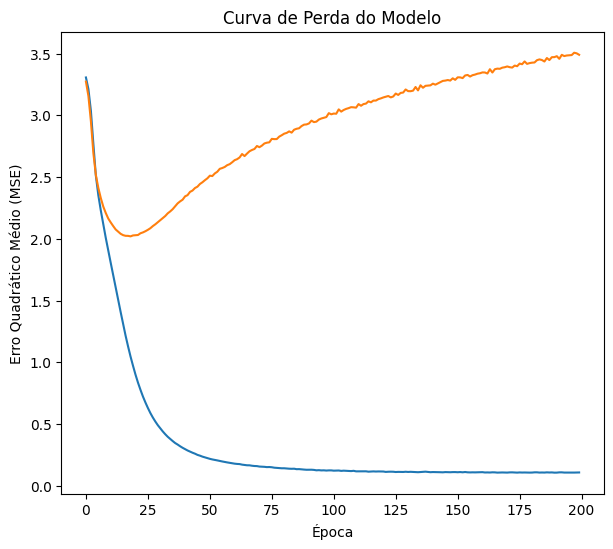

In [18]:
plt.figure(figsize=(7, 6))
plt.plot(historico.history['loss'])
plt.plot(historico.history['val_loss'])
plt.title('Curva de Perda do Modelo')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.xlabel('Época')
plt.show()

In [20]:
previsoes_prob = modelo_sp.predict(X_teste)

classes_preditas = np.argmax(previsoes_prob, axis=1)
classes_reais =  np.argmax(saida_teste, axis=1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [21]:
print(classification_report(classes_reais, classes_preditas))

              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.16      0.80      0.27         5
           2       0.25      0.30      0.27        10
           3       0.25      0.07      0.11        14
           4       0.00      0.00      0.00         3
           5       1.00      0.25      0.40         4
           6       0.00      0.00      0.00         1
           7       0.38      0.22      0.28        36
           8       0.33      0.50      0.40         2
           9       0.20      0.27      0.23        26
          10       0.56      0.42      0.48        43
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         3
          17       0.67      0.20      0.31        30
          19       1.00    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


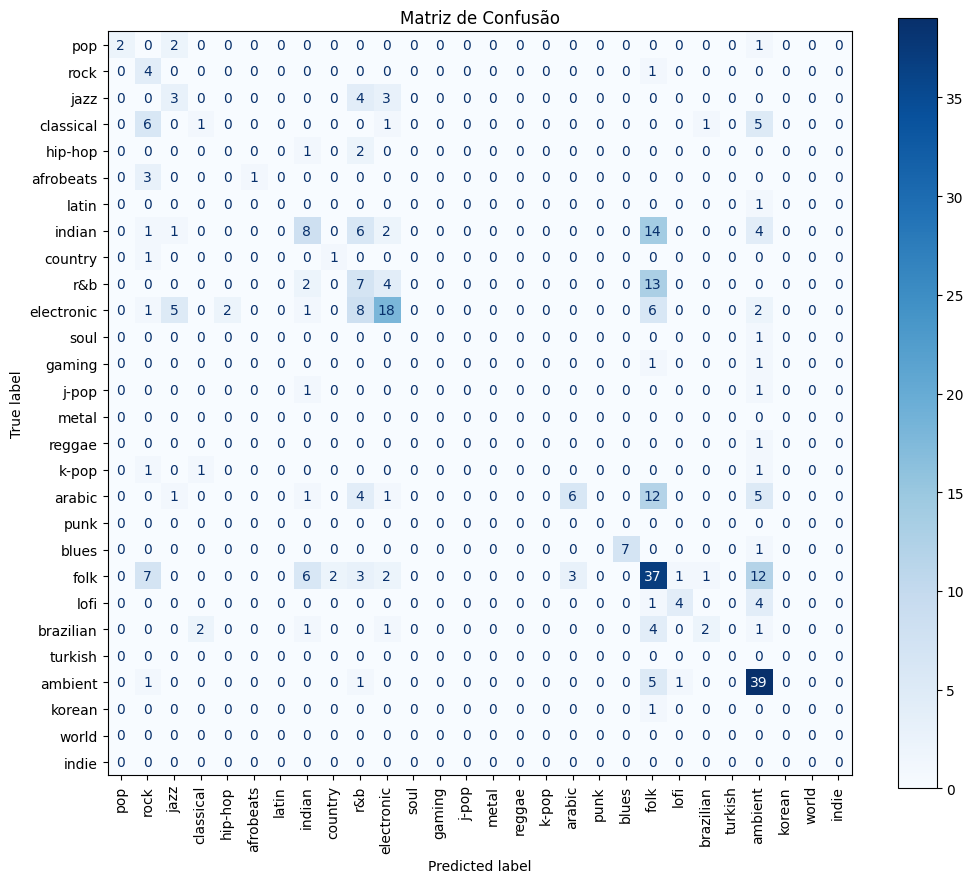

In [25]:
matriz_confusao = confusion_matrix(classes_reais, classes_preditas, labels=range(len(saida.unique())))

fig, ax = plt.subplots(figsize=(12, 10))
display_matriz = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=saida.unique())
display_matriz.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, xticks_rotation='vertical')
plt.title('Matriz de Confusão')
plt.show()

In [ ]:
explainer = shap.KernelExplainer(modelo_sp.predict, X_teste[:50])
shap_values = explainer.shap_values(X_teste)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


  0%|          | 0/338 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
3338/3338 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
class_names = list(label_encoder.classes_)

for i, class_name in enumerate(class_names):
  plt.figure(figsize=(6, 3))
  plt.title(f"Explicação SHAP para Classe: {class_name}")
  shap_val_class = shap_values[:, :, i]

  shap.summary_plot(shap_val_class, X_teste, feature_names=list(colunas_numericas))
  plt.show()